# experiments.py
Conducts the specified experiments on the simple CNN model to evaluate efficiency and accuracy

# Assignment 3
### CSC 537: Deep Learning

**Author:** Xander Palermo — ajp2s@missouristate.edu
**Professor:** Mukulika Ghosh
**Date:** 3 April 2026

----

## Imports

Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision.models as models
import pickle

from cnn import *  # custom class implementation

Imported helper functions (from prev. assignments)

In [7]:
plot_path = "./results/"

def save_plot (exp_plot, exp_num, exp_name, suffix = "") -> None:
    """
    Saves a plot to designated location
    :param exp_plot: the experiment's plot
    :param exp_num: the experiment's number
    :param exp_name: the experiment's name
    :param suffix: (optional) a title suffix to differentiate plots from the same experiment
    :return: None
    """
    file_type = ".png"
    complete_path = plot_path + f"exp_{exp_num}/{exp_name}" + suffix + file_type
    exp_plot.savefig(complete_path)
    print(f'\t\t saved to {complete_path}')


def gen_plot(df: pd.DataFrame,
             independent_var : str,
             experiment_number: int, experiment_title: str,
             dependent_var: str = "Loss",
             subtitle : str = None
             ) -> sns.FacetGrid:
    """
    generates a grid of plots for the experiment
    :param df: DataFrame containing data to be plotted. Data Frame should have a column containing Iterations, and 2 columns mapping Independent Variable -> Dependent Variable
    :param independent_var: the variable that is being changed for each execution of the gradient descent algorithm
    :param experiment_number: The experiment number
    :param experiment_title: The experiment title
    :param dependent_var: (DEFAULT: LOSS) the value to be tracked over iterations
    :param subtitle: (DEFAULT: none included) a descriptor of what the graph displays
    :return:
    """
    g = sns.relplot(
        data=df,
        kind='line', x='Epoch', y=dependent_var,
        hue=independent_var, legend=True
    )
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(f"Experiment {experiment_number}: {experiment_title}")
    if subtitle is not None:
        g.fig.text(0.5, 0.91, subtitle, ha='center', fontsize=10, color='gray')
    return g


Custom Helper Function (derived from save_plot)

In [8]:
def save_table(df : pd.DataFrame, exp_num, exp_name, suffix = "") -> None:
    """
    Saves a dataframe as a table to designated location.

    Saves as Microsoft Excel spreadsheet
    :param df: the experiment's plot
    :param exp_num: the experiment's number
    :param exp_name: the experiment's name
    :param suffix: (optional) a title suffix to differentiate plots from the same experiment
    :return: None
    """
    file_type = ".xlsx"
    complete_path = plot_path + f"exp_{exp_num}/{exp_name}" + suffix + file_type
    df.to_excel(complete_path)
    print(f'\t\t saved to {complete_path}')

## Start Up

Unpickle compiled DataLoader Objects

In [9]:
path = "./dataset/"
with open(path + "training.pkl", 'rb') as f:
    training_data = pickle.load(f)

with open(path + "validation.pkl", 'rb') as f:
    validation_data = pickle.load(f)

with open(path + "testing.pkl", 'rb') as f:
    testing_data = pickle.load(f)

Initialize GPU (if available)

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device == torch.device('cuda'):
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 2060


---

## Experiment A
*Depth Comparison*
Compare convergence behavior and validation behavior on models with varying depth.

In [ ]:
experiment_title = "Depth Comparison"
experiment_number = 1
independent_variable = "Depth"

**Independent Variables**

In [ ]:
shallow_network = SimpleCNN(2) # Control
deep_network = SimpleCNN(3)

### Experiment

Perform Training and Validation on models and capture statistical data
Each network is given 100 epoches to train over, to study how overfitting occurs in both models
Each network is also individually timed

In [ ]:
%%time
print("Starting Training on shallow network...")
shallow_network, shallow_train_loss, shallow_valid_loss, shallow_valid_accuracy = train(shallow_network, training_data, validation_data, verbose=True, device=device, TOTAL_EPOCHES=100)
print("Training on shallow network complete!")

torch.cuda.synchronize()

In [ ]:
%%time
print("Starting Testing on deep network...")
deep_network, deep_train_loss, deep_verify_loss, deep_valid_accuracy = train(deep_network, training_data, validation_data, verbose=True, device=device,  TOTAL_EPOCHES=100 )
print("Testing on deep network complete!")

torch.cuda.synchronize()

Perform final testing on models and capture statistical data

In [ ]:
shallow_test_loss, shallow_test_accuracy = [], []
deep_test_loss, deep_test_accuracy = [], []

In [ ]:
%%time
print("Starting Testing on shallow network complete!")
evaluate(shallow_network, testing_data, shallow_test_loss, shallow_test_accuracy)
print("Testing on shallow network complete!")

torch.cuda.synchronize()

In [ ]:
%%time
print("Starting Testing on deep network complete!")
evaluate(deep_network, testing_data, deep_test_loss, deep_test_accuracy)
print("Testing on deep network complete!")

torch.cuda.synchronize()

### Plotting

Construct DataFrame objects to compare each stage of training

In [ ]:
training_loss = pd.DataFrame({
    "Shallow"   : shallow_train_loss,
    "Deep"      : deep_train_loss,
})

validation_loss =  pd.DataFrame({
    "Shallow"   : shallow_valid_loss,
    "Deep"      : deep_verify_loss,
})

validation_accuracy =  pd.DataFrame({
    "Shallow"   : shallow_valid_accuracy,
    "Deep"      : deep_valid_accuracy,
})

plot_data_loss = {
    "Training Loss" : training_loss,
    "Validation Loss" : validation_loss
}

results = pd.DataFrame({
    "Model": ["Shallow", "Deep"],
    "Test Loss": [shallow_test_loss[0], deep_test_loss[0]],
    "Test Accuracy (%)": [shallow_test_accuracy[0], deep_test_accuracy[0]]
})

Prepare DataFrame and plot results generated by the loss function

In [ ]:
plots = dict()

In [ ]:
for identifier, df in plot_data_loss.items():
    df["Epoch"] = df.index
    df = pd.melt(df, id_vars=["Epoch"], var_name=independent_variable, value_name="Loss")
    # print(df)
    plots[identifier] = gen_plot(df, independent_variable, experiment_number, experiment_title, subtitle=identifier)
    plt.show()

Prepare DataFrame containing validation accuracy data and plot

In [ ]:
validation_accuracy["Epoch"] = validation_accuracy.index
validation_accuracy = pd.melt(validation_accuracy, id_vars=["Epoch"], var_name=independent_variable, value_name="Accuracy")
# print(df)
plots["Validation Accuracy"] = gen_plot(validation_accuracy, independent_variable, experiment_number, experiment_title, dependent_var="Accuracy", subtitle="Validation Accuracy")
plt.show()

Construct table of final test results

In [ ]:
results.set_index("Model", inplace=True)
display(results)

Save all figures to disk

In [ ]:
for identifier, g in plots.items():
    save_plot(g, experiment_number, experiment_title, suffix=f" - {identifier}")

save_table(results, experiment_number, experiment_title, suffix=f" - Results")


---

## Experiment B
*Architecture Comparison*
Comparing Simple CNN-Deep with a ResNet architecture to study how optimizations made in ResNet affect performance

In [11]:
experiment_title = "Architecture Comparison"
experiment_number = 2
independent_variable = "Architecture"

**Independent Variables**

Initialize each model

In [12]:
simple_cnn = SimpleCNN(depth=3)

resnet = models.resnet18(weights=None)
resnet.fc = torch.nn.Linear(resnet.fc.in_features, 10)


Count Trainable parameters in each model

In [13]:
print("Trainable Parameters:")
cnn_params = sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad)
resnet_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)

print(f'\t{"Simple CNN:":13} {cnn_params:,}')
print(f'\t{"ResNet:":13} {resnet_params:,}')

Trainable Parameters:
	Simple CNN:   483,402
	ResNet:       11,181,642


### Experiment

Perform Training and Validation on models and capture statistical data
*Notes*

- Epsilon is set to prevent overfitting and provide more information about convergence speed

- Each network is also individually timed

In [ ]:
thresh = 0.001

In [14]:
%%time
print("Starting training on Simple CNN...")
simple_cnn, simple_train_loss, simple_valid_loss, simple_valid_accuracy = train(simple_cnn, training_data, validation_data, verbose=True, device=device, THRESH= 0.001)
print("Training on Simple CNN complete!")

torch.cuda.synchronize()

Starting training on Simple CNN...
		Epoch 1/5
			training avg_loss=1.8434
			validation avg_loss=1.7612
			accuracy=33.85%
Training on Simple CNN complete!
CPU times: total: 16.2 s
Wall time: 3min 14s


In [15]:
%%time
print("Starting training on ResNet...")
resnet, rn_train_loss, rn_valid_loss, rn_valid_accuracy = train(resnet, training_data, validation_data, verbose=True, device=device, THRESH= 0.001)
print("Training on ResNet complete!")

torch.cuda.synchronize()

Starting training on ResNet...
		Epoch 1/5
			training avg_loss=1.9630
			validation avg_loss=2.0214
			accuracy=30.85%
Training on ResNet complete!
CPU times: total: 30.7 s
Wall time: 3min 3s


Perform final testing on models and capture statistical data

In [16]:
simple_test_loss, simple_test_accuracy = [], []
rn_test_loss, rn_test_accuracy = [], []

In [17]:
%%time
print("Starting testing on Simple CNN...")
evaluate(simple_cnn, testing_data, simple_test_loss, simple_test_accuracy)
print("Testing on Simple CNN complete!")

torch.cuda.synchronize()

Starting testing on Simple CNN...
Testing on Simple CNN complete!
CPU times: total: 4.41 s
Wall time: 21.2 s


In [18]:
%%time
print("Starting testing on ResNet...")
evaluate(resnet, testing_data, rn_test_loss, rn_test_accuracy)
print("Testing on ResNet complete!")

torch.cuda.synchronize()

Starting testing on ResNet...
Testing on ResNet complete!
CPU times: total: 4.5 s
Wall time: 23.8 s


### Plotting

Construct DataFrame objects to compare each stage of training


In [19]:
training_loss = pd.DataFrame({
    "Simple CNN"    : simple_train_loss ,
    "ResNet"        : rn_train_loss ,
})

validation_loss = pd.DataFrame({
    "Simple CNN"    : simple_valid_loss ,
    "ResNet"        : rn_valid_loss ,
})

validation_accuracy = pd.DataFrame({
    "Simple CNN"    : simple_valid_accuracy ,
    "ResNet"        : rn_valid_accuracy ,
})

plot_data_loss = {
    "Training Loss" : training_loss,
    "Validation Loss" : validation_loss
}

results = results = pd.DataFrame({
    "Architecture": ["Simple CNN", "ResNet"],
    "Test Loss": [simple_test_loss[0], rn_test_loss[0]],
    "Test Accuracy (%)": [simple_test_accuracy[0], rn_test_accuracy[0]]
})

Prepare DataFrame and plot results generated by the loss function

In [20]:
plots = dict()

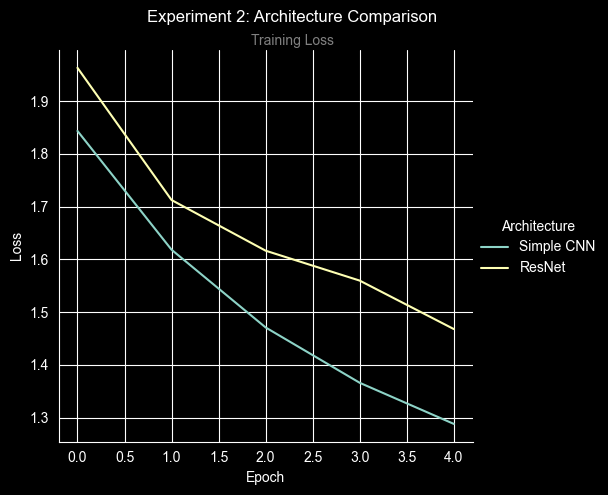

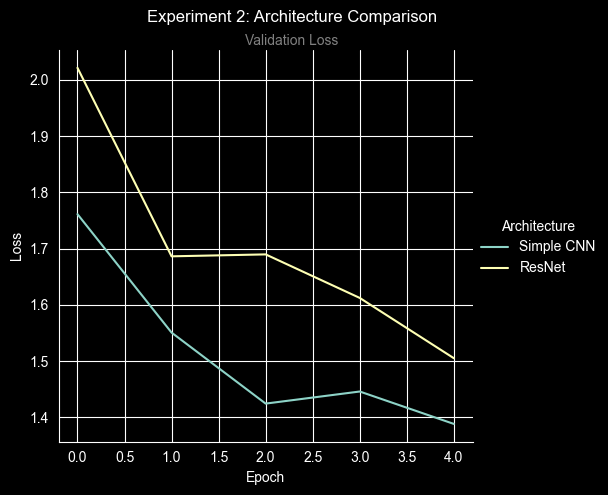

In [21]:
for identifier, df in plot_data_loss.items():
    df["Epoch"] = df.index
    df = pd.melt(df, id_vars=["Epoch"], var_name=independent_variable, value_name="Loss")
    # print(df)
    plots[identifier] = gen_plot(df, independent_variable, experiment_number, experiment_title, subtitle=identifier)
    plt.show()

Prepare DataFrame containing validation accuracy data and plot

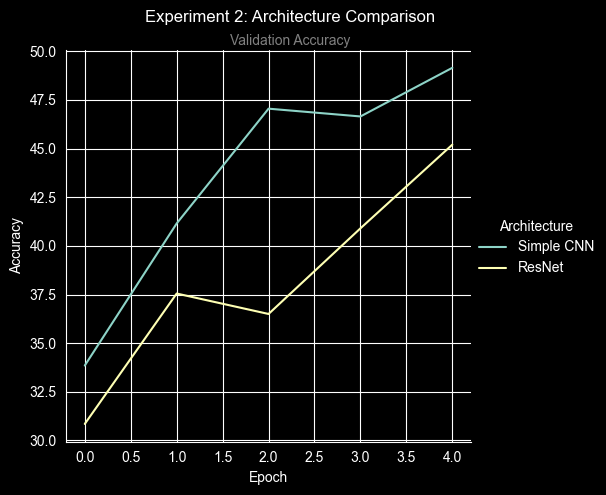

In [22]:
validation_accuracy["Epoch"] = validation_accuracy.index
validation_accuracy = pd.melt(validation_accuracy, id_vars=["Epoch"], var_name=independent_variable, value_name="Accuracy")
# print(df)
plots["Validation Accuracy"] = gen_plot(validation_accuracy, independent_variable, experiment_number, experiment_title, dependent_var="Accuracy", subtitle="Validation Accuracy")
plt.show()

Construct table of final test results

In [23]:
results.set_index("Architecture", inplace=True)
display(results)

,Test Loss,Test Accuracy (%)
Architecture,,
Simple CNN,1.046471,60.50
ResNet,1.357303,50.45


Save all figures to disk

In [24]:
for identifier, g in plots.items():
    save_plot(g, experiment_number, experiment_title, suffix=f" - {identifier}")

save_table(results, experiment_number, experiment_title, suffix=f" - Results")

		 saved to ./results/exp_2/Architecture Comparison - Training Loss.png
		 saved to ./results/exp_2/Architecture Comparison - Validation Loss.png
		 saved to ./results/exp_2/Architecture Comparison - Validation Accuracy.png
		 saved to ./results/exp_2/Architecture Comparison - results.xlsx


---

## Experiment C
Optimizers Comparison